# Ridge Linear Regression Code from Scratch

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

In [12]:
X, y = make_regression(n_samples=100, n_features=1, noise=30, random_state=42)

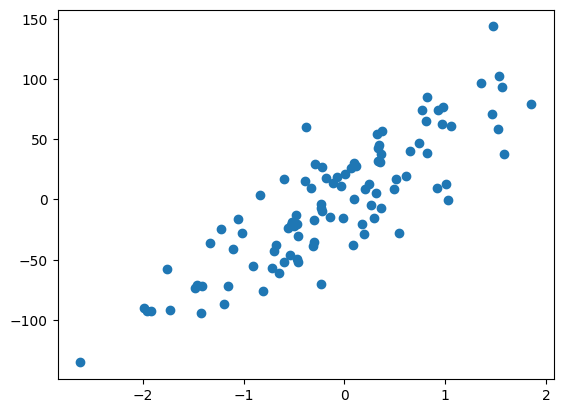

In [13]:
plt.scatter(X, y)

In [ ]:
def linear_regression(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    model = Pipeline(
        [
            ("model", LinearRegression())
        ]
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    print("Coefficient:", model.named_steps["model"].coef_)
    print("Intercept:", model.named_steps["model"].intercept_)
    
    
    plt.scatter(X, y)
    plt.plot(X_test, y_pred, color="red")
    
    return model
    

In [67]:
def ridge_regression(X, y, alpha, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = Pipeline([("model", Ridge(alpha=alpha))])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    print("Coefficient:", model.named_steps["model"].coef_)
    print("Intercept:", model.named_steps["model"].intercept_)
    
    # plt.scatter(X, y)
    # plt.plot(X_test, y_pred, color="red")


    return model

R2 Score: 0.6538826156165654
RMSE: 30.62384755034599
Coefficient: [49.25034584]
Intercept: 0.2976666426776342


Pipeline(steps=[('model', LinearRegression())])

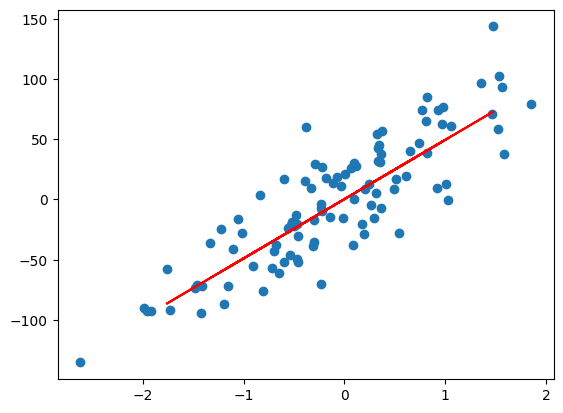

In [35]:
linear_regression(X, y)

R2 Score: 0.6373983115817208
RMSE: 31.344616352541895
Coefficient: [44.4901262]
Intercept: -0.314756762449937


Pipeline(steps=[('model', Ridge(alpha=7))])

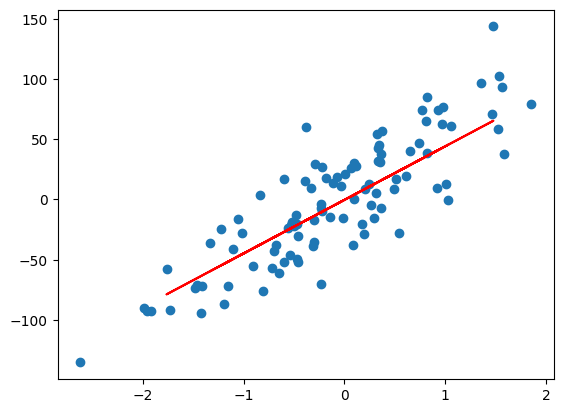

In [47]:
ridge_regression(X, y, alpha=7)

In [58]:
class MyRidge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        denom = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
            denom = (
                denom
                + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())
                
            )

        self.m = num / (denom + self.alpha)
        self.b = y_train.mean() - (self.m * X_train.mean())
        
        print(self.m, self.b)

    def predict(self, X_test):
        return self.m * X_test + self.b

In [63]:
def my_ridge_regression(X, y, alpha=0.1, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = Pipeline([("model", MyRidge(alpha=alpha))])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    print("Coefficient:", model.named_steps["model"].m)
    print("Intercept:", model.named_steps["model"].b)
    
    # plt.scatter(X, y)
    # plt.plot(X_test, y_pred, color="red")


    return model

In [68]:
my_ridge_regression(X, y, 0.1)
print("----------------------")
ridge_regression(X, y, 0.1)

[49.1751816] [0.28799643]
R2 Score: 0.653728185322067
RMSE: 30.630678646679115
Coefficient: [49.1751816]
Intercept: [0.28799643]
----------------------
R2 Score: 0.653728185322067
RMSE: 30.630678646679115
Coefficient: [49.1751816]
Intercept: 0.2879964289102013


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Pipeline(steps=[('model', Ridge(alpha=0.1))])